In [ ]:
import sys, os
# Adjust depth based on notebook location relative to project root
_src_path = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'src'))
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)
from project_config import load_config

config    = load_config()
base_dir  = config['base_dir']
well_list = config['well_list']
well_meta = config.get('well_metadata', {})

print(f'Active experiment: {config.get("experiment_name", config.get("experiment_key", "?"))}')
print(f'Base dir: {base_dir}')

Feature: pRB_rB_ratio
Doses used: [ 0.    0.01  0.05  0.1   0.25  0.5   1.    2.    5.   10.  ]
IC50: 5.687704841057768


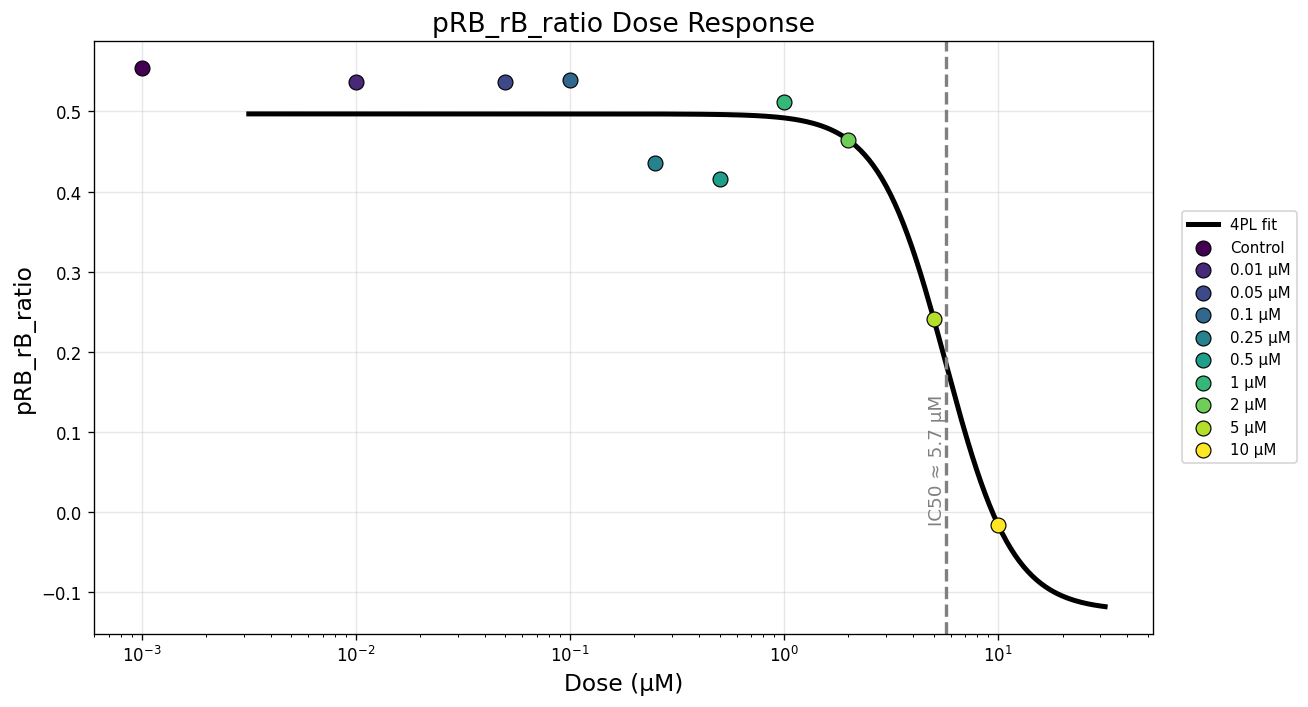

Feature: pS6_S6_ratio
Doses used: [ 0.    0.01  0.05  0.1   0.25  0.5   1.    2.    5.   10.  ]
IC50: 0.10606622427740947


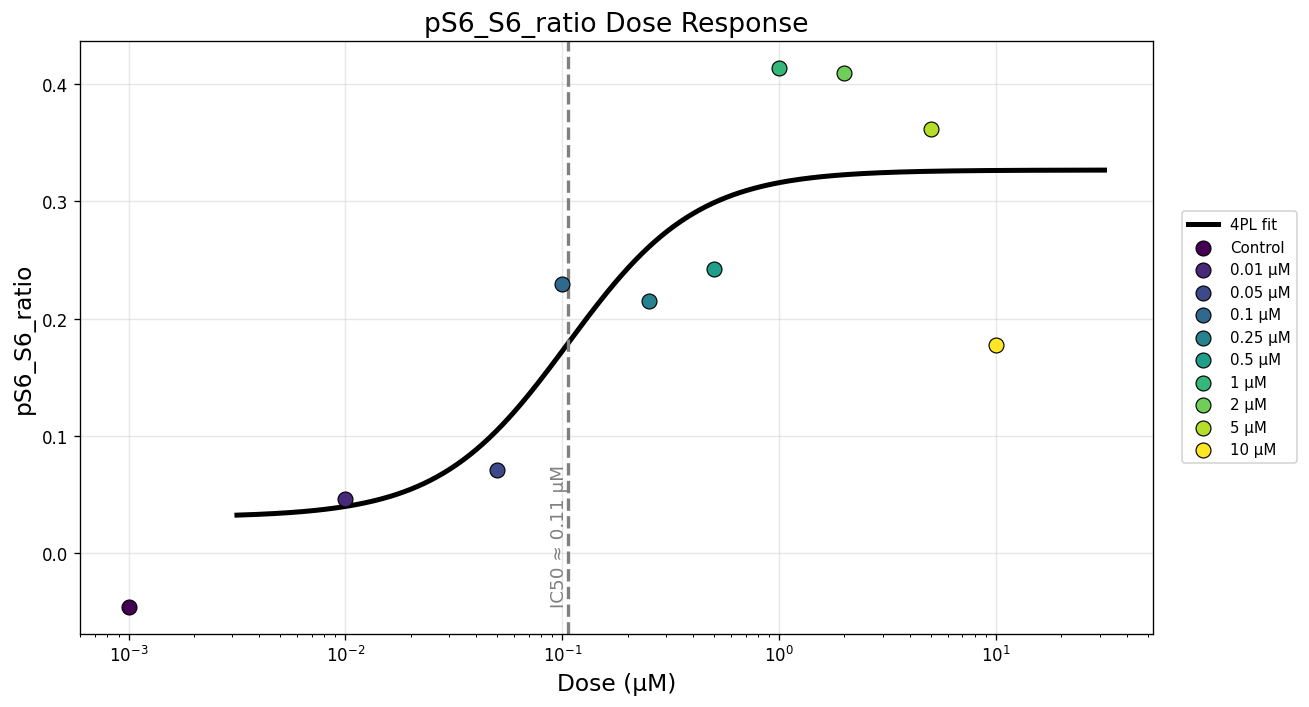


Summary:
        feature   IC50_uM
0  pRB_rB_ratio  5.687705
1  pS6_S6_ratio  0.106066


In [17]:
# ============================================================
# IC50 from Sample_* CSV files (fixed version)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit
import re

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['figure.dpi'] = 120

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------

CSV_BASE = Path(
    r"D:\Lauryn\Liposarcoma_2025\LPS_246_CVT_Tagto_Alp_Nov_2025"
    r"\split_analysis\analysis_csv_files\tagto_split_pRB_CSV_files\pRB_high"
)

FEATURE_FILES = {
    "pRB_rB_ratio": CSV_BASE / "pRB_rB_ratio_individual_columns.csv",
    "pS6_S6_ratio": CSV_BASE / "pS6_S6_ratio_individual_columns.csv",
}

AGGREGATION = "median"

# Your true dose series (must match number of Sample columns)
DOSES_UM = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 1, 2, 5, 10]


# ---------------------------------------------------------------------------
# 4PL model
# ---------------------------------------------------------------------------

def four_param_logistic_log10(x_log10, bottom, top, logIC50, hill):
    return bottom + (top - bottom) / (1.0 + 10.0 ** ((logIC50 - x_log10) * hill))


def fit_ic50(pos_doses, pos_responses):

    x_log10 = np.log10(pos_doses)

    bottom0 = np.min(pos_responses)
    top0 = np.max(pos_responses)
    logIC50_0 = np.median(x_log10)
    hill0 = 1.0

    p0 = [bottom0, top0, logIC50_0, hill0]

    bounds = (
        [bottom0 - 5, bottom0 - 1e-6, np.min(x_log10) - 3, -10],
        [top0 + 1e-6, top0 + 5, np.max(x_log10) + 3, 10],
    )

    popt, pcov = curve_fit(
        four_param_logistic_log10,
        x_log10,
        pos_responses,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )

    bottom, top, logIC50, hill = popt
    IC50 = 10 ** logIC50

    return popt, IC50


# ---------------------------------------------------------------------------
# Aggregate Sample_* columns using fixed dose mapping
# ---------------------------------------------------------------------------

def aggregate_from_sample_csv(path, doses_uM, agg="median"):

    df = pd.read_csv(path)

    sample_cols = [c for c in df.columns if c.lower().startswith("sample_")]

    if not sample_cols:
        raise ValueError("No Sample_* columns found.")

    # sort by numeric part of Sample_X
    def sample_number(col):
        m = re.search(r"sample_(\d+)", col.lower())
        return int(m.group(1)) if m else 9999

    sample_cols = sorted(sample_cols, key=sample_number)

    if len(sample_cols) != len(doses_uM):
        raise ValueError(
            f"Found {len(sample_cols)} Sample columns but "
            f"{len(doses_uM)} doses were provided.\n"
            f"Sample columns: {sample_cols}"
        )

    doses = []
    responses = []

    for col, dose in zip(sample_cols, doses_uM):

        values = pd.to_numeric(df[col], errors="coerce").dropna()

        if values.empty:
            print(f"Skipping {col} — empty column.")
            continue

        if agg == "median":
            resp = values.median()
        else:
            resp = values.mean()

        doses.append(float(dose))
        responses.append(float(resp))

    doses = np.array(doses)
    responses = np.array(responses)

    pos_mask = doses > 0

    return (
        doses,
        responses,
        doses[pos_mask],
        responses[pos_mask],
    )


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_dose_response(doses, responses, pos_doses, pos_responses, popt, IC50, feature):

    fig, ax = plt.subplots(figsize=(11, 6))

    # ---- color map per dose ----
    cmap = plt.get_cmap("viridis")
    unique_doses = np.sort(np.unique(doses))
    dose_to_color = {
        d: cmap(i / max(1, len(unique_doses) - 1))
        for i, d in enumerate(unique_doses)
    }

    # ---- smooth 4PL curve ----
    x_fit = np.linspace(
        np.log10(pos_doses.min()) - 0.5,
        np.log10(pos_doses.max()) + 0.5,
        400,
    )
    y_fit = four_param_logistic_log10(x_fit, *popt)

    ax.plot(10 ** x_fit, y_fit, color="black", linewidth=3, label="4PL fit")

    # ---- scatter each dose separately for legend ----
    plotted_labels = set()

    for d, r in zip(doses, responses):

        if d == 0:
            x_val = pos_doses.min() / 10
            label = "Control"
        else:
            x_val = d
            label = f"{d:g} µM"

        show_label = label not in plotted_labels
        if show_label:
            plotted_labels.add(label)

        ax.scatter(
            x_val,
            r,
            s=80,
            color=dose_to_color[d],
            edgecolor="black",
            linewidth=0.7,
            label=label if show_label else None,
            zorder=3,
        )

    # ---- IC50 line ----
    ax.axvline(IC50, linestyle="--", color="gray", linewidth=2)
    ax.text(
        IC50,
        responses.min(),
        f"IC50 ≈ {IC50:.2g} µM",
        rotation=90,
        va="bottom",
        ha="right",
        fontsize=11,
        color="gray",
    )

    ax.set_xscale("log")
    ax.set_xlabel("Dose (µM)", fontsize=14)
    ax.set_ylabel(feature, fontsize=14)
    ax.set_title(f"{feature} Dose Response", fontsize=16)

    ax.grid(alpha=0.3)

    # ---- legend to right ----
    ax.legend(
        frameon=True,
        fontsize=9,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
    )

    plt.tight_layout()
    plt.show()
# ---------------------------------------------------------------------------
# MAIN LOOP
# ---------------------------------------------------------------------------

ic50_results = []

for feature, path in FEATURE_FILES.items():

    print("=" * 80)
    print("Feature:", feature)

    doses, responses, pos_doses, pos_responses = aggregate_from_sample_csv(
        path,
        DOSES_UM,
        agg=AGGREGATION,
    )

    popt, IC50 = fit_ic50(pos_doses, pos_responses)

    ic50_results.append(
        {
            "feature": feature,
            "IC50_uM": IC50,
        }
    )

    print("Doses used:", doses)
    print("IC50:", IC50)

    plot_dose_response(
        doses,
        responses,
        pos_doses,
        pos_responses,
        popt,
        IC50,
        feature,
    )

print("\nSummary:")
print(pd.DataFrame(ic50_results))

In [18]:
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Single-cell correlation across ALL doses for pRB vs pS6
# =========================================================

# 1) Which features to correlate (match your filenames)
X_FEATURE = "pRB_rB_ratio"
Y_FEATURE = "pS6_S6_ratio"

# 2) Get IC50 for the X feature from the summary table
IC50_for_scatter = ic50_df.loc[
    ic50_df["feature"] == X_FEATURE, "IC50_uM"
].iloc[0]

print(f"Using IC50 for {X_FEATURE}: {IC50_for_scatter:.4g} µM")

# 3) Load the single-cell CSVs for both features from the same folder
x_path = CSV_BASE / f"{X_FEATURE}_individual_columns.csv"
y_path = CSV_BASE / f"{Y_FEATURE}_individual_columns.csv"

print(f"Loading X from: {x_path}")
print(f"Loading Y from: {y_path}")

df_x = pd.read_csv(x_path)
df_y = pd.read_csv(y_path)

# 4) Build a long-format dataframe with ALL doses
meta_cols = {"Treatment", "Dose"}  # skip if present
all_chunks = []

for col in df_x.columns:
    if col in meta_cols:
        continue

    dose_uM = parse_dose_to_uM(col)
    if not np.isfinite(dose_uM):
        print(f"Skipping column '{col}' — could not parse dose.")
        continue

    if col not in df_y.columns:
        print(f"Skipping column '{col}' — not found in Y dataframe.")
        continue

    # Pair up x/y for this condition and drop rows where either is NaN
    tmp = pd.DataFrame({
        "x": pd.to_numeric(df_x[col], errors="coerce"),
        "y": pd.to_numeric(df_y[col], errors="coerce"),
    }).dropna()

    if tmp.empty:
        continue

    tmp["dose_uM"] = dose_uM
    tmp["dose_label"] = col
    all_chunks.append(tmp)

if not all_chunks:
    raise ValueError("No usable dose columns found for correlation plot.")

df_all = pd.concat(all_chunks, ignore_index=True)
print(f"Total single cells used across all doses: {len(df_all)}")

# 5) Compute correlation and regression across ALL single cells
x = df_all["x"].values
y = df_all["y"].values
dose_vals = df_all["dose_uM"].values

pear_r, pear_p = pearsonr(x, y)
m, b = np.polyfit(x, y, 1)  # y = m*x + b
x_line = np.linspace(x.min(), x.max(), 300)
y_line = m * x_line + b

# 6) Plot: all doses, with a discrete color per dose
fig, ax = plt.subplots(figsize=(12, 8))

unique_doses = np.sort(df_all["dose_uM"].unique())
cmap = plt.get_cmap("viridis")

# map each distinct dose to a color
dose_to_color = {
    d: cmap(i / max(1, len(unique_doses) - 1))
    for i, d in enumerate(unique_doses)
}

# scatter, one dose at a time so each dose has its own color + legend entry
plotted_labels = set()
for d in unique_doses:
    mask = df_all["dose_uM"] == d
    x_d = df_all.loc[mask, "x"].values
    y_d = df_all.loc[mask, "y"].values

    if d == 0:
        label = "Control"
    else:
        label = f"{d:g} µM"

    show_label = label not in plotted_labels
    if show_label:
        plotted_labels.add(label)

    ax.scatter(
        x_d, y_d,
        s=15,
        alpha=0.6,
        color=dose_to_color[d],
        edgecolor="none",
        label=label if show_label else None,
    )

# regression line across ALL cells
ax.plot(
    x_line, y_line,
    color="red",
    linewidth=2.2,
    label=f"Linear fit (slope = {m:.2f})"
)

ax.set_title(
    f"Alp — ALL doses (IC50 for {X_FEATURE} ≈ {IC50_for_scatter:.2g} µM)\n"
    f"Single-Cell Plot: {X_FEATURE} vs {Y_FEATURE}",
    fontsize=18
)
ax.set_xlabel("pRB / RB", fontsize=14)
ax.set_ylabel("pS6 / S6", fontsize=14)
ax.grid(alpha=0.3)

# ---- Correlation textbox, moved outside to the right ----
if pear_p < 1e-300:
    p_str = "p < 1e-300"
else:
    p_str = f"p = {pear_p:.2e}"

ax.text(
    1.02, 0.95,  # x, y in axes coordinates (outside the plot)
    f"Pearson r = {pear_r:.3f}\n{p_str}",
    transform=ax.transAxes,
    fontsize=14,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.85)
)

# ---- Legend outside right ----
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
)

plt.tight_layout()
plt.show()



Using IC50 for pRB_rB_ratio: 0.01 µM
Loading X from: D:\Lauryn\Liposarcoma_2025\LPS_246_CVT_Tagto_Alp_Nov_2025\split_analysis\analysis_csv_files\tagto_split_pRB_CSV_files\pRB_high\pRB_rB_ratio_individual_columns.csv
Loading Y from: D:\Lauryn\Liposarcoma_2025\LPS_246_CVT_Tagto_Alp_Nov_2025\split_analysis\analysis_csv_files\tagto_split_pRB_CSV_files\pRB_high\pS6_S6_ratio_individual_columns.csv
Skipping column 'Sample_1' — could not parse dose.
Skipping column 'Sample_11' — could not parse dose.
Skipping column 'Sample_12' — could not parse dose.
Skipping column 'Sample_13' — could not parse dose.
Skipping column 'Sample_14' — could not parse dose.
Skipping column 'Sample_15' — could not parse dose.
Skipping column 'Sample_16' — could not parse dose.
Skipping column 'Sample_17' — could not parse dose.
Skipping column 'Sample_18' — could not parse dose.
Skipping column 'Sample_19' — could not parse dose.


ValueError: No usable dose columns found for correlation plot.

Using IC50 for pRB_rB_ratio: 5.017 µM
Loading X from: D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_CVT_Tagto_Alp_Nov_2025\split_analysis\analysis_csv_files\alp_split_pRB_csv_files\pRB_high\pRB_rB_ratio_individual_columns.csv
Loading Y from: D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_CVT_Tagto_Alp_Nov_2025\split_analysis\analysis_csv_files\alp_split_pRB_csv_files\pRB_high\pS6_S6_ratio_individual_columns.csv
Closest dose column to IC50: '3 uM Alp'  (dose ≈ 3 µM)
Number of single cells at this dose: 1483


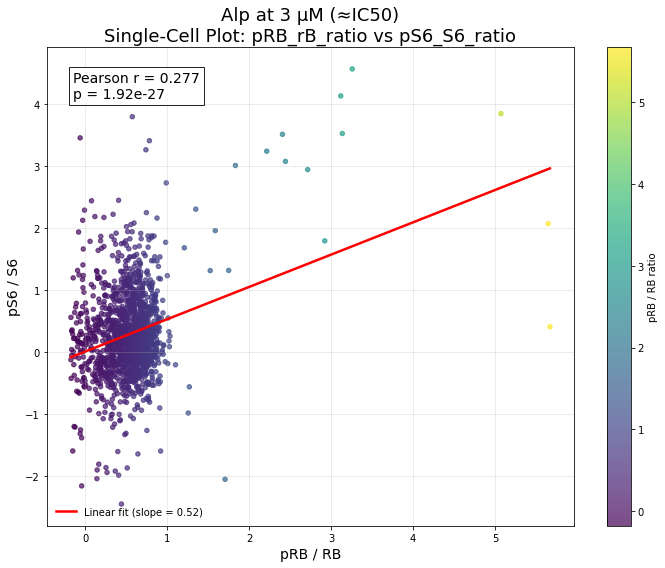

In [4]:
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Single-cell correlation at (≈) IC50 for pRB vs pS6
# =========================================================

# 1) Which features to correlate (match your filenames)
X_FEATURE = "pRB_rB_ratio"
Y_FEATURE = "pS6_S6_ratio"

# 2) Get IC50 for the X feature from the summary table
#    (ic50_df was created at the end of your existing script)
IC50_for_scatter = ic50_df.loc[
    ic50_df["feature"] == X_FEATURE, "IC50_uM"
].iloc[0]

print(f"Using IC50 for {X_FEATURE}: {IC50_for_scatter:.4g} µM")

# 3) Load the single-cell CSVs for both features from the same folder
x_path = CSV_BASE / f"{X_FEATURE}_individual_columns.csv"
y_path = CSV_BASE / f"{Y_FEATURE}_individual_columns.csv"

print(f"Loading X from: {x_path}")
print(f"Loading Y from: {y_path}")

df_x = pd.read_csv(x_path)
df_y = pd.read_csv(y_path)

# 4) Helper: find the column whose header dose is closest to the IC50
def find_closest_dose_column(columns, target_ic50):
    """
    Given a list of column names like '0 Control', '0.01 uM Alp', etc.,
    return (best_col_name, best_dose_uM) where best_dose_uM is closest to target_ic50.
    """
    best_col = None
    best_dose = None
    best_diff = np.inf

    for col in columns:
        # skip metadata columns if present
        if col in ("Treatment", "Dose"):
            continue

        d = parse_dose_to_uM(col)
        if not np.isfinite(d) or d <= 0:
            continue

        diff = abs(d - target_ic50)
        if diff < best_diff:
            best_diff = diff
            best_col = col
            best_dose = d

    if best_col is None:
        raise ValueError("Could not find any positive-dose columns to match IC50.")

    return best_col, best_dose

# 5) Find the closest dose column using the X dataframe (they share headers)
closest_col, closest_dose = find_closest_dose_column(df_x.columns, IC50_for_scatter)
print(f"Closest dose column to IC50: '{closest_col}'  (dose ≈ {closest_dose:.4g} µM)")

# Sanity check: make sure that column exists in both dataframes
if closest_col not in df_y.columns:
    raise KeyError(
        f"Column '{closest_col}' found in X dataframe but not in Y dataframe."
    )

# 6) Build df_sub with single-cell values at that (≈IC50) column
df_sub = pd.DataFrame({
    X_FEATURE: pd.to_numeric(df_x[closest_col], errors="coerce"),
    Y_FEATURE: pd.to_numeric(df_y[closest_col], errors="coerce"),
}).dropna()

print(f"Number of single cells at this dose: {len(df_sub)}")

# 7) Now your correlation + line code using df_sub
x = df_sub[X_FEATURE].values
y = df_sub[Y_FEATURE].values

# Pearson correlation
pear_r, pear_p = pearsonr(x, y)

# Linear regression line
m, b = np.polyfit(x, y, 1)      # y = m*x + b
x_line = np.linspace(x.min(), x.max(), 300)
y_line = m * x_line + b

# Plot
plt.figure(figsize=(10, 8))

sc = plt.scatter(
    x, y,
    c=x, cmap="viridis",
    s=20, alpha=0.7
)
cb = plt.colorbar(sc)
cb.set_label("pRB / RB ratio")

plt.plot(
    x_line, y_line,
    color="red", linewidth=2.5,
    label=f"Linear fit (slope = {m:.2f})"
)

plt.title(
    f"Alp at {closest_dose:.3g} µM (≈IC50)\n"
    f"Single-Cell Plot: {X_FEATURE} vs {Y_FEATURE}",
    fontsize=18
)
plt.xlabel("pRB / RB", fontsize=14)
plt.ylabel("pS6 / S6", fontsize=14)
plt.grid(alpha=0.3)

if pear_p < 1e-300:
    p_str = "p < 1e-300"
else:
    p_str = f"p = {pear_p:.2e}"

plt.text(
    0.05, 0.95,
    f"Pearson r = {pear_r:.3f}\n{p_str}",
    transform=plt.gca().transAxes,
    fontsize=14,
    va="top",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.85)
)

plt.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()


In [3]:
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIG: which features to correlate
# -------------------------------------
X_FEATURE = "pRB_rB_ratio"
Y_FEATURE = "pS6_S6_ratio"

# df_cells: your single-cell dataframe with at least:
#   - a 'Dose_label' or similar string, e.g. "0.01 uM Alp"
#   - columns for X_FEATURE and Y_FEATURE
df_cells = pd.read_csv(r"PATH\to\your_single_cell_file.csv")

# If you only have a string like "0.01 uM Alp", convert once using your helper:
df_cells["Dose_uM"] = df_cells["Dose_label"].apply(parse_dose_to_uM)

# -------------------------------------
# pick the dose closest to the IC50
# (IC50 already computed in your earlier code)
# -------------------------------------
diff = np.abs(df_cells["Dose_uM"] - IC50)
closest_dose = df_cells.loc[diff.idxmin(), "Dose_uM"]

# Subset to that dose (≈ IC50)
df_sub = df_cells[df_cells["Dose_uM"] == closest_dose][[X_FEATURE, Y_FEATURE]].dropna()

# -------------------------------------
# Now your original plotting code works
# -------------------------------------
x = df_sub[X_FEATURE].values
y = df_sub[Y_FEATURE].values

# 1) Pearson correlation
pear_r, pear_p = pearsonr(x, y)

# 2) Linear regression line (the "actual line" for the correlation)
m, b = np.polyfit(x, y, 1)     # y = m*x + b
x_line = np.linspace(x.min(), x.max(), 300)
y_line = m * x_line + b

# 3) Plot
plt.figure(figsize=(10, 8))

# Scatter of single cells, colored by x-feature
sc = plt.scatter(
    x, y,
    c=x, cmap="viridis",
    s=20, alpha=0.7
)
cb = plt.colorbar(sc)
cb.set_label(X_FEATURE)

# Regression line
plt.plot(
    x_line, y_line,
    color="red", linewidth=2.5,
    label=f"Linear fit (slope = {m:.2f})"
)

plt.title(
    f"Alp at {closest_dose:.3g} µM (≈IC50)\n"
    f"Single-Cell Plot: {X_FEATURE} vs {Y_FEATURE}",
    fontsize=18
)
plt.xlabel(X_FEATURE, fontsize=14)
plt.ylabel(Y_FEATURE, fontsize=14)
plt.grid(alpha=0.3)

# Correlation text box
if pear_p < 1e-300:
    p_str = "p < 1e-300"
else:
    p_str = f"p = {pear_p:.2e}"

plt.text(
    0.05, 0.95,
    f"Pearson r = {pear_r:.3f}\n{p_str}",
    transform=plt.gca().transAxes,
    fontsize=14,
    va="top",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.85)
)

plt.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'PATH\\to\\your_single_cell_file.csv'

In [ ]:
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Single-cell scatter at (≈) IC50 with correlation + line
# ---------------------------------------------------------
x = df_sub[X_FEATURE].values
y = df_sub[Y_FEATURE].values

# 1) Pearson correlation
pear_r, pear_p = pearsonr(x, y)

# 2) Linear regression line (the "actual line" for the correlation)
m, b = np.polyfit(x, y, 1)     # y = m*x + b
x_line = np.linspace(x.min(), x.max(), 300)
y_line = m * x_line + b

# 3) Plot
plt.figure(figsize=(10, 8))

# Scatter of single cells, colored by pRB/RB (x)
sc = plt.scatter(
    x, y,
    c=x, cmap="viridis",
    s=20, alpha=0.7
)
cb = plt.colorbar(sc)
cb.set_label("pRB / RB ratio")

# Regression line
plt.plot(
    x_line, y_line,
    color="red", linewidth=2.5,
    label=f"Linear fit (slope = {m:.2f})"
)

# --- NO ZOOM --- (show full range)
# plt.xlim(...)  <-- removed on purpose

plt.title(
    f"Alp at {closest_dose} µM (≈IC50)\n"
    f"Single-Cell Plot: {X_FEATURE} vs {Y_FEATURE}",
    fontsize=18
)
plt.xlabel("pRB / RB", fontsize=14)
plt.ylabel("pS6 / S6", fontsize=14)
plt.grid(alpha=0.3)

# Correlation text box
if pear_p < 1e-300:
    p_str = "p < 1e-300"
else:
    p_str = f"p = {pear_p:.2e}"

plt.text(
    0.05, 0.95,
    f"Pearson r = {pear_r:.3f}\n{p_str}",
    transform=plt.gca().transAxes,
    fontsize=14,
    va="top",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.85)
)

plt.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()


NameError: name 'df_sub' is not defined

Unique doses: [1.e-02 3.e-02 1.e-01 3.e-01 1.e+00 3.e+00 1.e+01 2.e+01 3.e+01]
Below IC50 dose:  3.0
At IC50 dose:     10.0
Above IC50 dose:  20.0
Cells included: 42313


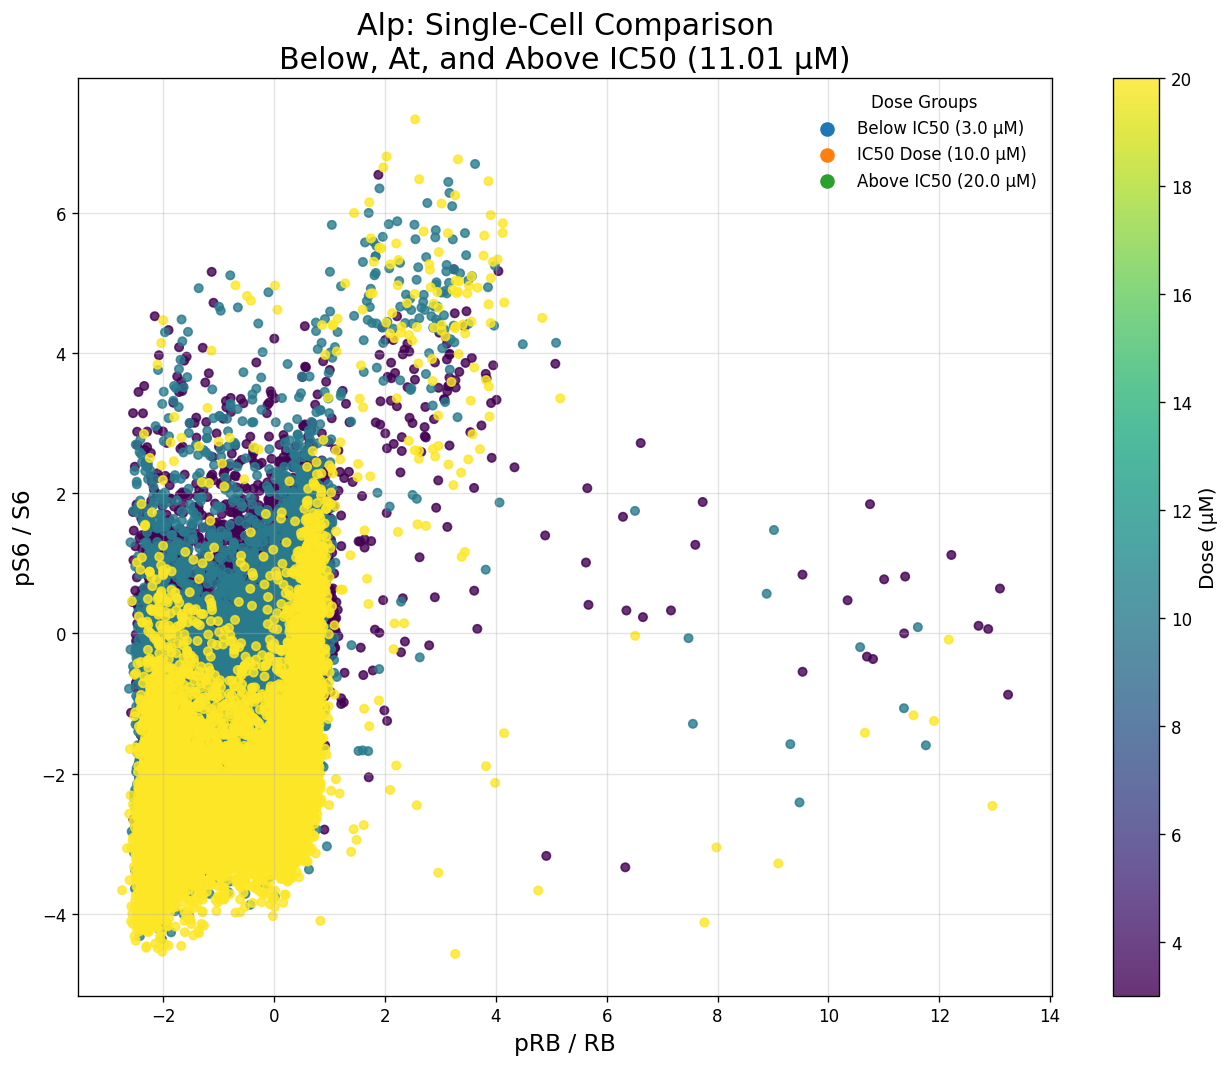

In [23]:
# ============================================================
# Plot cells BELOW, AT, and ABOVE IC50
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Features ---
X_FEATURE = "pRB_rB_ratio"
Y_FEATURE = "pS6_S6_ratio"
TREATMENT_OF_INTEREST = "Alp"

df = A.obs.copy()
df[X_FEATURE] = _col(A, X_FEATURE)
df[Y_FEATURE] = _col(A, Y_FEATURE)

def parse_dose(d):
    d = str(d).lower().strip()
    if "um" in d:
        d = d.replace("um", "")
    try:
        return float(d)
    except:
        return np.nan

df["dose_numeric"] = df["dose"].map(parse_dose)

# ---- Candidate doses for this drug ----
drug_df = df[df["treatment"] == TREATMENT_OF_INTEREST]
unique_doses = np.sort(drug_df["dose_numeric"].dropna().unique())
print("Unique doses:", unique_doses)

# ---- Find below, closest, and above IC50 ----
closest_idx = np.argmin(np.abs(unique_doses - IC50_value))

# IC50 dose:
dose_at = unique_doses[closest_idx]

# Below dose:
dose_below = unique_doses[closest_idx - 1] if closest_idx > 0 else None

# Above dose:
dose_above = unique_doses[closest_idx + 1] if closest_idx < len(unique_doses) - 1 else None

print(f"Below IC50 dose:  {dose_below}")
print(f"At IC50 dose:     {dose_at}")
print(f"Above IC50 dose:  {dose_above}")

# ---- Build a combined df for plotting ----
plot_df = pd.DataFrame()
labels = []

for d, label in [(dose_below, "Below IC50"), (dose_at, "IC50 Dose"), (dose_above, "Above IC50")]:
    if d is None:
        continue
    temp = drug_df[drug_df["dose_numeric"] == d].copy()
    temp["Dose_Label"] = f"{label} ({d} µM)"
    plot_df = pd.concat([plot_df, temp], ignore_index=True)

print("Cells included:", plot_df.shape[0])

# ---- Plotting ----
plt.figure(figsize=(11, 9))

scatter = plt.scatter(
    plot_df[X_FEATURE],
    plot_df[Y_FEATURE],
    s=25,
    alpha=0.8,
    c=plot_df["dose_numeric"],
    cmap="viridis"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Dose (µM)", fontsize=12)

plt.title(
    f"{TREATMENT_OF_INTEREST}: Single-Cell Comparison\n"
    f"Below, At, and Above IC50 ({IC50_value:.2f} µM)",
    fontsize=18
)

plt.xlabel("pRB / RB", fontsize=14)
plt.ylabel("pS6 / S6", fontsize=14)
plt.grid(alpha=0.35)

# ---- Legend for dose groups ----
for label in plot_df["Dose_Label"].unique():
    subset = plot_df[plot_df["Dose_Label"] == label]
    plt.scatter([], [], label=label, s=60)

plt.legend(title="Dose Groups", frameon=False)

plt.tight_layout()
plt.show()
